# BrainCell vs NEURON: 2x2 HH network

This notebook compares a minimal Hodgkin-Huxley network in BrainCell and NEURON. The example is intentionally small: two presynaptic single-soma HH cells connect all-to-all to two postsynaptic HH cells through `ExpSyn` synapses.

The first section calibrates the synaptic weight with direct `NetStim` events: one EPSP is subthreshold, two widely spaced EPSPs are still subthreshold, and two closely spaced EPSPs trigger a postsynaptic spike. The second section uses the same weight in a real 2x2 HH network driven by current clamps.


In [1]:
import os

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import brainunit as u
import brainstate


def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import braincell
import braincell.mech as mech
from braincell import Branch, CVPerBranch, Cell, Morphology
from braincell.filter import AllRegion, at

brainstate.environ.set(precision=64)

print("braincell version:", braincell.__version__)
print("repo_root:", repo_root)


braincell version: 0.1.0
repo_root: /home/swl/braincell


## Shared model parameters


In [2]:
DT_MS = 0.025
WARMUP_MS = 25.0
NETSTIM_DURATION_MS = 85.0
NETWORK_DURATION_MS = 115.0

SYN_WEIGHT_US = 0.001
SYN_TAU_MS = 2.0
SYN_E_MV = 0.0

SOMA_L_UM = 20.0
SOMA_DIAM_UM = 20.0
CM_UF_PER_CM2 = 1.0
RA_OHM_CM = 100.0
V_INIT_MV = -65.0
V_TH_MV = 0.0

ENA_MV = 50.0
EK_MV = -77.0
GNA_MS_PER_CM2 = 120.0
GK_MS_PER_CM2 = 36.0
GL_MS_PER_CM2 = 0.3
EL_MV = -54.387

NETSTIM_CASES = {
    "single": (40.0,),
    "wide pair": (40.0, 48.0),
    "close pair": (40.0, 40.5),
}

PRE_CLAMP_SCHEDULES = (
    (40.0, 60.0, 90.0),
    (68.0, 90.5),
)
EPOCHS = {
    "single input": (35.0, 55.0),
    "wide pair": (55.0, 80.0),
    "close pair": (85.0, 105.0),
}


In [3]:
def crossing_times_ms(time_ms, voltage_mV, threshold_mV=0.0, after_ms=0.0):
    voltage_mV = np.asarray(voltage_mV, dtype=float)
    cross = np.flatnonzero((voltage_mV[:-1] < threshold_mV) & (voltage_mV[1:] >= threshold_mV))
    times = np.asarray(time_ms, dtype=float)[cross + 1]
    return times[times >= after_ms]


def epoch_maxima(time_ms, voltage_2d, epochs=EPOCHS):
    voltage_2d = np.asarray(voltage_2d, dtype=float)
    return {
        name: np.max(voltage_2d[(time_ms >= start) & (time_ms <= stop)], axis=0)
        for name, (start, stop) in epochs.items()
    }


def spike_count_by_epoch(time_ms, voltage_2d, epochs=EPOCHS):
    voltage_2d = np.asarray(voltage_2d, dtype=float)
    counts = {}
    for name, (start, stop) in epochs.items():
        values = []
        for idx in range(voltage_2d.shape[1]):
            times = crossing_times_ms(time_ms, voltage_2d[:, idx], after_ms=start)
            values.append(int(np.sum(times <= stop)))
        counts[name] = np.asarray(values, dtype=int)
    return counts


def summarize_spikes(label, time_ms, voltage_2d, after_ms=30.0):
    print(label)
    for idx in range(voltage_2d.shape[1]):
        print(f"  cell[{idx}] crossings ms:", crossing_times_ms(time_ms, voltage_2d[:, idx], after_ms=after_ms))


def quantity_2d(value, unit):
    arr = np.asarray(value.to_decimal(unit), dtype=float)
    if arr.shape == ():
        return arr.reshape(1, 1)
    return arr.reshape(arr.shape[0], -1)


def prepend_initial_sample(time_ms, traces, initial_values):
    time_ms = np.asarray(time_ms, dtype=float)
    if time_ms.size == 0:
        raise ValueError("time_ms must not be empty.")
    out = {"time_ms": np.concatenate(([time_ms[0]], time_ms))}
    for key, values in traces.items():
        values = np.asarray(values, dtype=float)
        initial = np.asarray(initial_values[key], dtype=float)
        if values.ndim == 1:
            out[key] = np.concatenate(([float(initial.reshape(()))], values))
        else:
            out[key] = np.concatenate((initial.reshape(1, -1), values), axis=0)
    return out


## BrainCell helpers


In [4]:
def build_braincell_soma_morphology() -> Morphology:
    soma = Branch.from_lengths(
        lengths=[SOMA_L_UM] * u.um,
        radii=[SOMA_DIAM_UM / 2.0, SOMA_DIAM_UM / 2.0] * u.um,
        type="soma",
    )
    return Morphology.from_root(soma, name="soma")


def add_braincell_hh_membrane(cell: Cell) -> None:
    cell.paint(
        AllRegion(),
        mech.CableProperty(
            resting_potential=V_INIT_MV * u.mV,
            membrane_capacitance=CM_UF_PER_CM2 * (u.uF / u.cm**2),
            axial_resistivity=RA_OHM_CM * (u.ohm * u.cm),
        ),
        mech.Ion("SodiumFixed", E=ENA_MV * u.mV),
        mech.Ion("PotassiumFixed", E=EK_MV * u.mV),
        mech.Channel("Na_HH1952", g_max=GNA_MS_PER_CM2 * (u.mS / u.cm**2)),
        mech.Channel("K_HH1952", g_max=GK_MS_PER_CM2 * (u.mS / u.cm**2)),
        mech.Channel("IL", g_max=GL_MS_PER_CM2 * (u.mS / u.cm**2), E=EL_MV * u.mV),
    )


def build_braincell_hh_cell(*, pop_size=None, name=None) -> Cell:
    kwargs = {} if pop_size is None else {"pop_size": pop_size}
    cell = Cell(
        build_braincell_soma_morphology(),
        cv_policy=CVPerBranch(),
        solver="staggered",
        V_init=V_INIT_MV * u.mV,
        V_th=V_TH_MV * u.mV,
        name=name,
        **kwargs,
    )
    add_braincell_hh_membrane(cell)
    return cell


def initialize_braincell_cell(cell: Cell) -> None:
    cell.init_state()
    cell.reset_state()


def build_braincell_netstim_cell(event_times_ms, *, syn_weight_uS=SYN_WEIGHT_US) -> Cell:
    cell = build_braincell_hh_cell()
    for index, event_time_ms in enumerate(event_times_ms):
        cell.place(
            at("soma", 0.5),
            mech.NetStim(
                name=f"stim_{index}",
                start=event_time_ms * u.ms,
                number=1,
                interval=10.0 * u.ms,
                noise=0.0,
                weight=syn_weight_uS,
            ),
        )
    cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))
    cell.place(at("soma", 0.5), mech.MechanismProbe(name="g", mechanism="exp", field="g"))
    cell.place(at("soma", 0.5), mech.CurrentProbe(name="i_syn", mechanism="exp"))
    cell.place(
        at("soma", 0.5),
        mech.Synapse(
            "ExpSyn",
            tau=SYN_TAU_MS * u.ms,
            e=SYN_E_MV * u.mV,
            weight=1.0 * u.uS,
            name="exp",
        ),
    )
    return cell


def run_braincell_netstim_case(event_times_ms):
    cell = build_braincell_netstim_cell(event_times_ms)
    initialize_braincell_cell(cell)
    cell.run(dt=DT_MS * u.ms, duration=WARMUP_MS * u.ms)
    initial_time_ms = float(np.asarray(cell.current_time.to_decimal(u.ms), dtype=float))
    initial_values = {
        "voltage_mV": quantity_2d(cell.V.value, u.mV)[0, 0],
        "g_uS": 0.0,
        "current_nA": 0.0,
    }
    result = cell.run(dt=DT_MS * u.ms, duration=NETSTIM_DURATION_MS * u.ms)
    time_ms = np.asarray(result.time.to_decimal(u.ms), dtype=float)
    data = prepend_initial_sample(
        time_ms,
        {
            "voltage_mV": quantity_2d(result.traces["v"], u.mV)[:, 0],
            "g_uS": quantity_2d(result.traces["g"], u.uS)[:, 0],
            "current_nA": quantity_2d(result.traces["i_syn"], u.nA)[:, 0],
        },
        initial_values,
    )
    data["time_ms"][0] = initial_time_ms
    return data


In [5]:
def build_braincell_pre_population() -> Cell:
    cell = build_braincell_hh_cell(pop_size=(2,), name="pre")
    event_clamps = []
    for cell_index, schedule in enumerate(PRE_CLAMP_SCHEDULES):
        for event_time_ms in schedule:
            amplitudes_nA = np.zeros(2, dtype=float)
            amplitudes_nA[cell_index] = 1.0
            event_clamps.append((event_time_ms, amplitudes_nA))
    for event_time_ms, amplitudes_nA in sorted(event_clamps, key=lambda item: item[0]):
        cell.place(
            at("soma", 0.5),
            mech.CurrentClamp(
                delay=event_time_ms * u.ms,
                durations=0.1 * u.ms,
                amplitudes=u.Quantity(amplitudes_nA, u.nA),
            ),
        )
    cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))
    return cell


def build_braincell_post_population() -> Cell:
    cell = build_braincell_hh_cell(pop_size=(2,), name="post")
    cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))
    cell.place(at("soma", 0.5), mech.MechanismProbe(name="g_syn", mechanism="exp", field="g"))
    cell.place(at("soma", 0.5), mech.CurrentProbe(name="i_syn", mechanism="exp"))
    cell.place(
        at("soma", 0.5),
        mech.Synapse(
            "ExpSyn",
            tau=SYN_TAU_MS * u.ms,
            e=SYN_E_MV * u.mV,
            weight=1.0 * u.uS,
            name="exp",
        ),
    )
    return cell


def run_braincell_network():
    pre = build_braincell_pre_population()
    post = build_braincell_post_population()
    for cell in (pre, post):
        initialize_braincell_cell(cell)
    initial_time_ms = float(np.asarray(pre.current_time.to_decimal(u.ms), dtype=float))
    initial_values = {
        "pre_v_mV": quantity_2d(pre.V.value, u.mV).reshape(1, -1)[0],
        "post_v_mV": quantity_2d(post.V.value, u.mV).reshape(1, -1)[0],
        "post_g_uS": np.zeros(2, dtype=float),
        "post_i_nA": np.zeros(2, dtype=float),
    }
    net = braincell.Network(name="hh_2x2")
    net.add_population("pre", pre)
    net.add_population("post", post)
    edges = net.add_edges(
        name="pre_to_post",
        pre="pre",
        post="post",
        method=braincell.network.all_to_all(),
    )
    net.add_projection(
        name="pre_to_post_exp",
        edges="pre_to_post",
        synapse_pool="exp",
        weight=SYN_WEIGHT_US * u.uS,
        delay=1.0 * u.ms,
    )
    result = net.run(dt=DT_MS * u.ms, duration=NETWORK_DURATION_MS * u.ms)
    time_ms = np.asarray(result.time.to_decimal(u.ms), dtype=float)
    data = prepend_initial_sample(
        time_ms,
        {
            "pre_v_mV": quantity_2d(result.traces["pre"]["v"], u.mV),
            "post_v_mV": quantity_2d(result.traces["post"]["v"], u.mV),
            "post_g_uS": quantity_2d(result.traces["post"]["g_syn"], u.uS),
            "post_i_nA": quantity_2d(result.traces["post"]["i_syn"], u.nA),
        },
        initial_values,
    )
    data["time_ms"][0] = initial_time_ms
    data["edges"] = list(zip(edges.pre_index.tolist(), edges.post_index.tolist()))
    return data


## NEURON helpers


In [6]:
def make_neuron_hh_soma(name):
    from neuron import h

    sec = h.Section(name=name)
    sec.L = SOMA_L_UM
    sec.diam = SOMA_DIAM_UM
    sec.nseg = 1
    sec.cm = CM_UF_PER_CM2
    sec.Ra = RA_OHM_CM
    sec.insert("hh")
    sec.ena = ENA_MV
    sec.ek = EK_MV
    for seg in sec:
        seg.hh.gnabar = GNA_MS_PER_CM2 / 1000.0
        seg.hh.gkbar = GK_MS_PER_CM2 / 1000.0
        seg.hh.gl = GL_MS_PER_CM2 / 1000.0
        seg.hh.el = EL_MV
    return sec


def configure_neuron_fixed_step(dt_ms=DT_MS):
    from neuron import h

    h.load_file("stdrun.hoc")
    h.cvode_active(0)
    h.dt = dt_ms
    h.steps_per_ms = 1.0 / dt_ms
    h.v_init = V_INIT_MV


def run_neuron_netstim_case(event_times_ms):
    from neuron import h

    configure_neuron_fixed_step()
    soma = make_neuron_hh_soma("post")
    syn = h.ExpSyn(soma(0.5))
    syn.tau = SYN_TAU_MS
    syn.e = SYN_E_MV
    stims = []
    netcons = []
    for event_time_ms in event_times_ms:
        stim = h.NetStim()
        stim.start = event_time_ms
        stim.number = 1
        stim.interval = 10.0
        stim.noise = 0.0
        nc = h.NetCon(stim, syn)
        nc.weight[0] = SYN_WEIGHT_US
        nc.delay = 0.0
        stims.append(stim)
        netcons.append(nc)

    t_vec = h.Vector().record(h._ref_t)
    v_vec = h.Vector().record(soma(0.5)._ref_v)
    g_vec = h.Vector().record(syn._ref_g)
    i_vec = h.Vector().record(syn._ref_i)
    try:
        h.finitialize(V_INIT_MV)
        h.tstop = WARMUP_MS + NETSTIM_DURATION_MS
        h.run()
        time_ms = np.asarray(t_vec, dtype=float)
        keep = time_ms >= WARMUP_MS
        return {
            "time_ms": time_ms[keep],
            "voltage_mV": np.asarray(v_vec, dtype=float)[keep],
            "g_uS": np.asarray(g_vec, dtype=float)[keep],
            "current_nA": np.asarray(i_vec, dtype=float)[keep],
        }
    finally:
        h.delete_section(sec=soma)


def run_neuron_network():
    from neuron import h

    configure_neuron_fixed_step()
    pre = [make_neuron_hh_soma(f"pre_{idx}") for idx in range(2)]
    post = [make_neuron_hh_soma(f"post_{idx}") for idx in range(2)]
    clamps = []
    for sec, schedule in zip(pre, PRE_CLAMP_SCHEDULES):
        for event_time_ms in schedule:
            clamp = h.IClamp(sec(0.5))
            clamp.delay = event_time_ms
            clamp.dur = 0.1
            clamp.amp = 1.0
            clamps.append(clamp)

    syns = []
    netcons = []
    for post_sec in post:
        syn = h.ExpSyn(post_sec(0.5))
        syn.tau = SYN_TAU_MS
        syn.e = SYN_E_MV
        syns.append(syn)
        for pre_sec in pre:
            nc = h.NetCon(pre_sec(0.5)._ref_v, syn, sec=pre_sec)
            nc.threshold = V_TH_MV
            nc.delay = 1
            nc.weight[0] = SYN_WEIGHT_US
            netcons.append(nc)

    t_vec = h.Vector().record(h._ref_t)
    pre_v_vecs = [h.Vector().record(sec(0.5)._ref_v) for sec in pre]
    post_v_vecs = [h.Vector().record(sec(0.5)._ref_v) for sec in post]
    post_g_vecs = [h.Vector().record(syn._ref_g) for syn in syns]
    post_i_vecs = [h.Vector().record(syn._ref_i) for syn in syns]

    try:
        h.finitialize(V_INIT_MV)
        h.tstop = NETWORK_DURATION_MS
        h.run()
        time_ms = np.asarray(t_vec, dtype=float)
        return {
            "time_ms": time_ms,
            "pre_v_mV": np.column_stack([np.asarray(vec, dtype=float) for vec in pre_v_vecs]),
            "post_v_mV": np.column_stack([np.asarray(vec, dtype=float) for vec in post_v_vecs]),
            "post_g_uS": np.column_stack([np.asarray(vec, dtype=float) for vec in post_g_vecs]),
            "post_i_nA": np.column_stack([np.asarray(vec, dtype=float) for vec in post_i_vecs]),
        }
    finally:
        for sec in pre + post:
            h.delete_section(sec=sec)


## Stage 1: direct event calibration


In [7]:
bc_netstim = {name: run_braincell_netstim_case(times) for name, times in NETSTIM_CASES.items()}
nrn_netstim = {name: run_neuron_netstim_case(times) for name, times in NETSTIM_CASES.items()}

print(f"synaptic event weight: {SYN_WEIGHT_US} uS")
for name in NETSTIM_CASES:
    bc_spikes = crossing_times_ms(bc_netstim[name]["time_ms"], bc_netstim[name]["voltage_mV"], after_ms=30.0)
    nrn_spikes = crossing_times_ms(nrn_netstim[name]["time_ms"], nrn_netstim[name]["voltage_mV"], after_ms=30.0)
    print(f"{name:10s} BrainCell spikes={bc_spikes}  NEURON spikes={nrn_spikes}")

assert len(crossing_times_ms(bc_netstim["single"]["time_ms"], bc_netstim["single"]["voltage_mV"], after_ms=30.0)) == 0
assert len(crossing_times_ms(bc_netstim["wide pair"]["time_ms"], bc_netstim["wide pair"]["voltage_mV"], after_ms=30.0)) == 0
assert len(crossing_times_ms(bc_netstim["close pair"]["time_ms"], bc_netstim["close pair"]["voltage_mV"], after_ms=30.0)) == 1
assert len(crossing_times_ms(nrn_netstim["single"]["time_ms"], nrn_netstim["single"]["voltage_mV"], after_ms=30.0)) == 0
assert len(crossing_times_ms(nrn_netstim["wide pair"]["time_ms"], nrn_netstim["wide pair"]["voltage_mV"], after_ms=30.0)) == 0
assert len(crossing_times_ms(nrn_netstim["close pair"]["time_ms"], nrn_netstim["close pair"]["voltage_mV"], after_ms=30.0)) == 1


synaptic event weight: 0.001 uS
single     BrainCell spikes=[]  NEURON spikes=[]
wide pair  BrainCell spikes=[]  NEURON spikes=[]
close pair BrainCell spikes=[42.75]  NEURON spikes=[42.75]


--No graphics will be displayed.


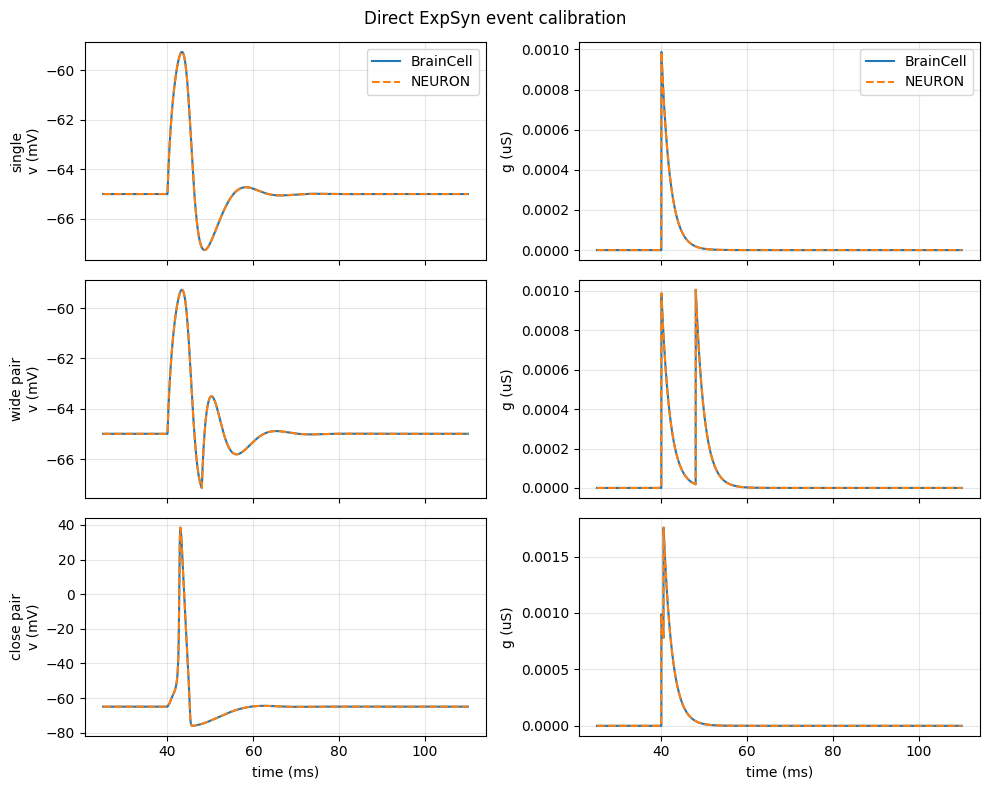

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
for row, name in enumerate(NETSTIM_CASES):
    axes[row, 0].plot(bc_netstim[name]["time_ms"], bc_netstim[name]["voltage_mV"], label="BrainCell")
    axes[row, 0].plot(nrn_netstim[name]["time_ms"], nrn_netstim[name]["voltage_mV"], linestyle="--", label="NEURON")
    axes[row, 0].set_ylabel(f"{name}\nv (mV)")
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 1].plot(bc_netstim[name]["time_ms"], bc_netstim[name]["g_uS"], label="BrainCell")
    axes[row, 1].plot(nrn_netstim[name]["time_ms"], nrn_netstim[name]["g_uS"], linestyle="--", label="NEURON")
    axes[row, 1].set_ylabel("g (uS)")
    axes[row, 1].grid(True, alpha=0.3)
axes[-1, 0].set_xlabel("time (ms)")
axes[-1, 1].set_xlabel("time (ms)")
axes[0, 0].legend()
axes[0, 1].legend()
fig.suptitle("Direct ExpSyn event calibration")
fig.tight_layout()
plt.show()


## Stage 2: 2x2 all-to-all HH network


In [9]:
bc_network = run_braincell_network()
nrn_network = run_neuron_network()

print("BrainCell edge pairs:", bc_network["edges"])
print("max |BrainCell post[0] - post[1]| mV:", np.max(np.abs(bc_network["post_v_mV"][:, 0] - bc_network["post_v_mV"][:, 1])))
print("max |NEURON post[0] - post[1]| mV:", np.max(np.abs(nrn_network["post_v_mV"][:, 0] - nrn_network["post_v_mV"][:, 1])))
summarize_spikes("BrainCell pre", bc_network["time_ms"], bc_network["pre_v_mV"])
summarize_spikes("BrainCell post", bc_network["time_ms"], bc_network["post_v_mV"])
summarize_spikes("NEURON pre", nrn_network["time_ms"], nrn_network["pre_v_mV"])
summarize_spikes("NEURON post", nrn_network["time_ms"], nrn_network["post_v_mV"])

expected_edges = [(0, 0), (0, 1), (1, 0), (1, 1)]
assert bc_network["edges"] == expected_edges, bc_network["edges"]

for idx in range(2):
    bc_pre_spikes = crossing_times_ms(bc_network["time_ms"], bc_network["pre_v_mV"][:, idx], after_ms=30.0)
    nrn_pre_spikes = crossing_times_ms(nrn_network["time_ms"], nrn_network["pre_v_mV"][:, idx], after_ms=30.0)
    assert bc_pre_spikes.shape == nrn_pre_spikes.shape, (idx, bc_pre_spikes, nrn_pre_spikes)
    max_diff_ms = np.max(np.abs(bc_pre_spikes - nrn_pre_spikes)) if bc_pre_spikes.size else 0.0
    print(f"max |BrainCell pre[{idx}] spike time - NEURON pre[{idx}] spike time| ms:", max_diff_ms)
    assert max_diff_ms <= DT_MS + 1e-9, (idx, max_diff_ms)

bc_counts = spike_count_by_epoch(bc_network["time_ms"], bc_network["post_v_mV"])
nrn_counts = spike_count_by_epoch(nrn_network["time_ms"], nrn_network["post_v_mV"])
print("BrainCell post spike counts by epoch:", bc_counts)
print("NEURON post spike counts by epoch:", nrn_counts)

expected = {
    "single input": np.asarray([0, 0]),
    "wide pair": np.asarray([0, 0]),
    "close pair": np.asarray([1, 1]),
}
for epoch_name, expected_counts in expected.items():
    assert np.array_equal(bc_counts[epoch_name], expected_counts), (epoch_name, bc_counts[epoch_name])
    assert np.array_equal(nrn_counts[epoch_name], expected_counts), (epoch_name, nrn_counts[epoch_name])


BrainCell edge pairs: [(0, 0), (0, 1), (1, 0), (1, 1)]
max |BrainCell post[0] - post[1]| mV: 0.0
max |NEURON post[0] - post[1]| mV: 0.0
BrainCell pre
  cell[0] crossings ms: [42.375 61.975 92.475]
  cell[1] crossings ms: [70.375 92.525]
BrainCell post
  cell[0] crossings ms: [95.95]
  cell[1] crossings ms: [95.95]
NEURON pre
  cell[0] crossings ms: [42.4 62.  92.5]
  cell[1] crossings ms: [70.4  92.55]
NEURON post
  cell[0] crossings ms: [96.]
  cell[1] crossings ms: [96.]
max |BrainCell pre[0] spike time - NEURON pre[0] spike time| ms: 0.025000000012454393
max |BrainCell pre[1] spike time - NEURON pre[1] spike time| ms: 0.025000000012468604
BrainCell post spike counts by epoch: {'single input': array([0, 0]), 'wide pair': array([0, 0]), 'close pair': array([1, 1])}
NEURON post spike counts by epoch: {'single input': array([0, 0]), 'wide pair': array([0, 0]), 'close pair': array([1, 1])}


The network section now uses one presynaptic population with two cells and one postsynaptic population with two cells. Each presynaptic current pulse is represented by one independent `CurrentClamp`, matching the NEURON `IClamp` construction. The two postsynaptic cells are intentionally identical and receive identical all-to-all input, so `post[0]` and `post[1]` should overlap exactly. They are plotted on separate axes below to avoid one trace hiding the other.

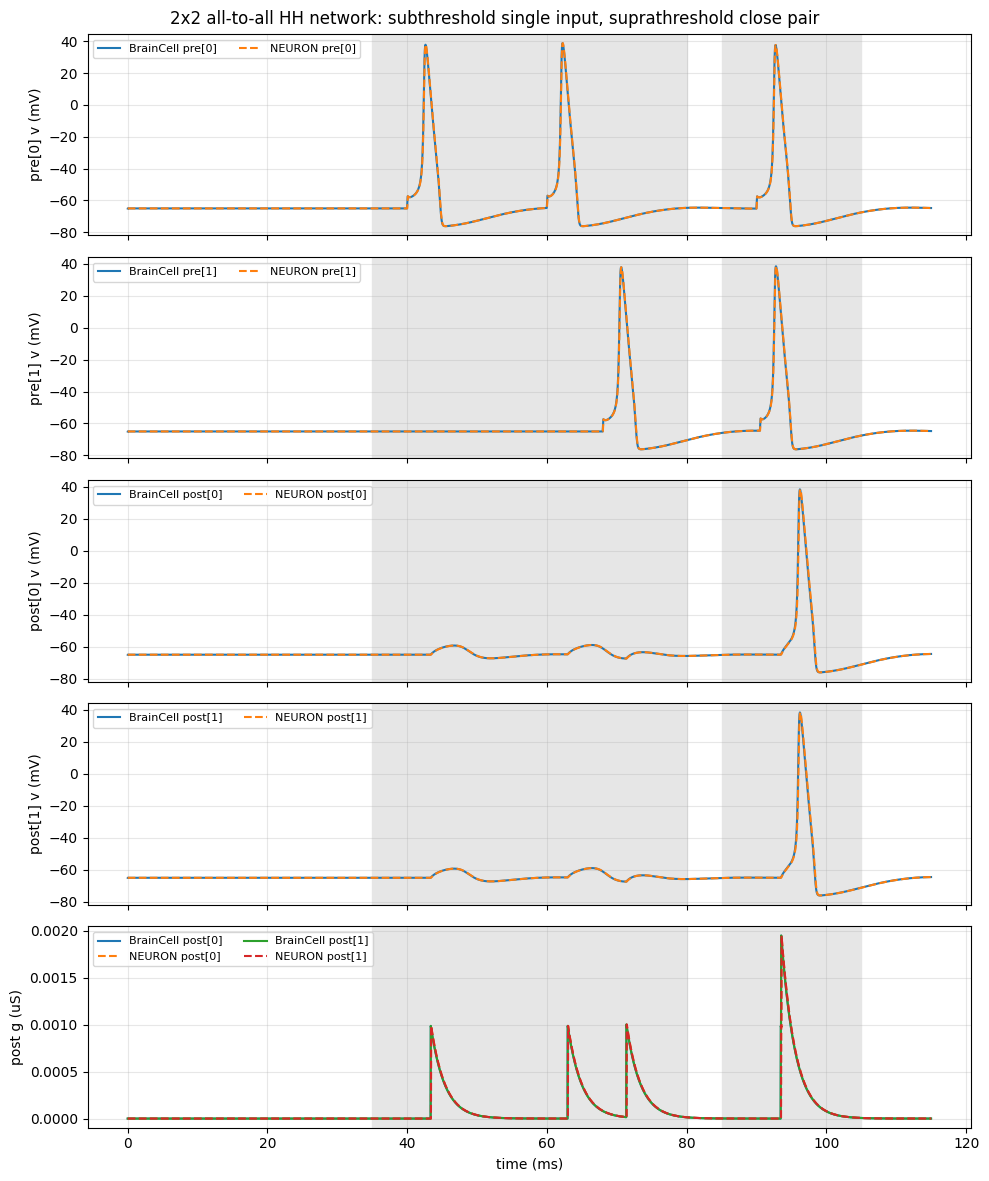

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

for idx, axis in enumerate(axes[:2]):
    axis.plot(bc_network["time_ms"], bc_network["pre_v_mV"][:, idx], label=f"BrainCell pre[{idx}]")
    axis.plot(nrn_network["time_ms"], nrn_network["pre_v_mV"][:, idx], linestyle="--", label=f"NEURON pre[{idx}]")
    axis.set_ylabel(f"pre[{idx}] v (mV)")
    axis.legend(ncol=2, fontsize=8)
    axis.grid(True, alpha=0.3)

for idx, axis in enumerate(axes[2:4]):
    axis.plot(bc_network["time_ms"], bc_network["post_v_mV"][:, idx], label=f"BrainCell post[{idx}]")
    axis.plot(nrn_network["time_ms"], nrn_network["post_v_mV"][:, idx], linestyle="--", label=f"NEURON post[{idx}]")
    axis.set_ylabel(f"post[{idx}] v (mV)")
    axis.legend(ncol=2, fontsize=8)
    axis.grid(True, alpha=0.3)

for idx in range(2):
    axes[4].plot(bc_network["time_ms"], bc_network["post_g_uS"][:, idx], label=f"BrainCell post[{idx}]")
    axes[4].plot(nrn_network["time_ms"], nrn_network["post_g_uS"][:, idx], linestyle="--", label=f"NEURON post[{idx}]")
axes[4].set_ylabel("post g (uS)")
axes[4].set_xlabel("time (ms)")
axes[4].legend(ncol=2, fontsize=8)
axes[4].grid(True, alpha=0.3)

for axis in axes:
    for start, stop in EPOCHS.values():
        axis.axvspan(start, stop, color="0.9", zorder=-1)
fig.suptitle("2x2 all-to-all HH network: subthreshold single input, suprathreshold close pair")
fig.tight_layout()
plt.show()


In [11]:
print("BrainCell post voltage maxima by epoch:")
for name, values in epoch_maxima(bc_network["time_ms"], bc_network["post_v_mV"]).items():
    print(f"  {name:12s}", values)

print("NEURON post voltage maxima by epoch:")
for name, values in epoch_maxima(nrn_network["time_ms"], nrn_network["post_v_mV"]).items():
    print(f"  {name:12s}", values)


BrainCell post voltage maxima by epoch:
  single input [-59.27007375 -59.27007375]
  wide pair    [-58.9326754 -58.9326754]
  close pair   [38.44955039 38.44955039]
NEURON post voltage maxima by epoch:
  single input [-59.27007375 -59.27007375]
  wide pair    [-58.9326754 -58.9326754]
  close pair   [38.44955039 38.44955039]
